# RQ1 — Pre-training Quality Analysis

This notebook inspects one run produced by `run_pretraining_quality.py`.

The main quantities are $\epsilon_S(t) = \frac{\|S(W_t)-S^\star\|_F^2}{\|S^\star\|_F^2}$ and the held-out pre-training generalization error $\epsilon_{\mathrm{pre}}(t).$

We inspect them against:
- raw SGD update count `step`;
- \(t/d\);
- \(t/d^2\).

The goal is to decide whether the current pre-training trajectory has converged enough and which saved checkpoints represent meaningfully different levels of pre-training quality before moving on to Task 1.

In [2]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
import torch

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


d=100  | step 450,000 / 100,000 (450.0%) | t/d² = 45.000 | eps_S = 0.018471 | eps_pre = 0.005238
d=200  | step 1,800,000 / 400,000 (450.0%) | t/d² = 45.000 | eps_S = 0.019935 | eps_pre = 0.005527
d=500  | step 6,250,000 / 2,500,000 (250.0%) | t/d² = 25.000 | eps_S = 0.082334 | eps_pre = 0.022301


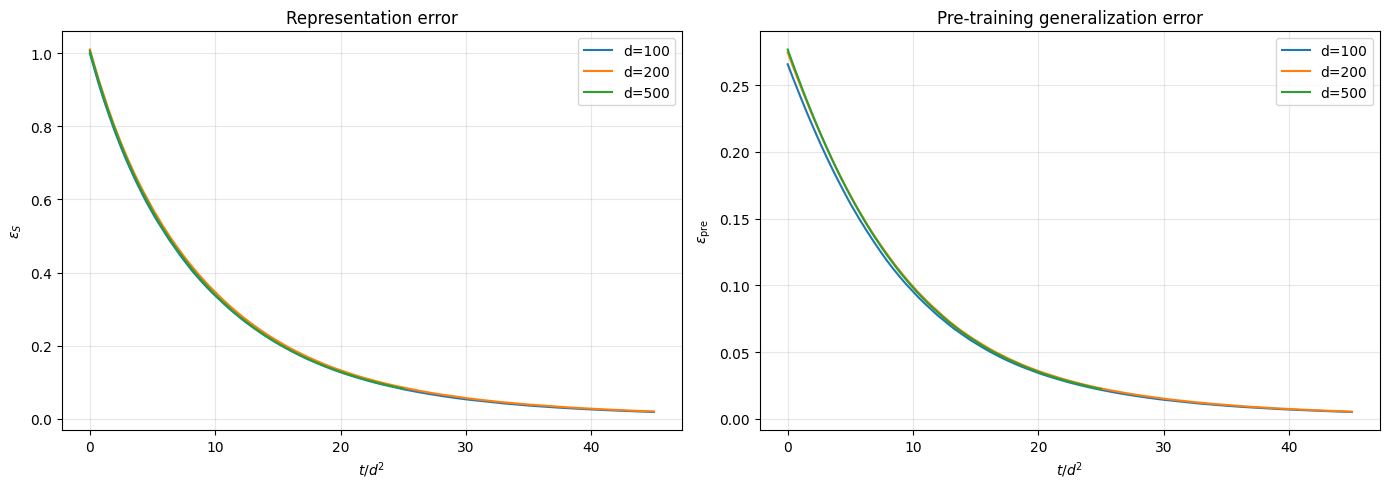

In [3]:
# ============================================================
# Live comparison of d = 100, 200, 500 runs
# ============================================================

RUNS = {
    "d=100": {
        "name": "scaling_d100_T5",
        "d": 100,
    },
    "d=200": {
        "name": "scaling_d200_T5",
        "d": 200,
    },
    "d=500": {
        "name": "scaling_d500_T5",
        "d": 500,
    },
}


cwd = Path.cwd()

if (cwd / "results").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "results").exists():
    REPO_ROOT = cwd.parent
else:
    # Fallback for a fresh checkout before results exist.
    REPO_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

RESULTS_ROOT = (
    REPO_ROOT
    / "results"
    / "quality_pretraining"
)


# ============================================================
# Load whatever has been produced so far
# ============================================================

runs = {}

for label, info in RUNS.items():

    run_dir = (
        RESULTS_ROOT
        / info["name"]
    )

    metrics_path = (
        run_dir
        / "metrics.csv"
    )

    if not metrics_path.exists():
        print(
            f"{label}: no metrics yet"
        )
        continue

    df = pd.read_csv(
        metrics_path
    )

    df = (
        df
        .sort_values("step")
        .drop_duplicates(
            subset="step",
            keep="last",
        )
        .reset_index(drop=True)
    )

    runs[label] = df

    d = info["d"]
    target = 10 * d**2
    current = int(df["step"].max())

    print(
        f"{label:6s} | "
        f"step {current:,} / {target:,} "
        f"({100 * current / target:.1f}%) | "
        f"t/d² = {current / d**2:.3f} | "
        f"eps_S = {df.iloc[-1]['representation_error']:.6f} | "
        f"eps_pre = {df.iloc[-1]['generalization_error']:.6f}"
    )


# ============================================================
# Plot current trajectories
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

for label, df in runs.items():

    axes[0].plot(
        df["step_over_d2"],
        df["representation_error"],
        label=label,
    )

    axes[1].plot(
        df["step_over_d2"],
        df["generalization_error"],
        label=label,
    )


# Representation error
axes[0].set_xlabel(r"$t/d^2$")
axes[0].set_ylabel(r"$\epsilon_S$")
axes[0].set_title("Representation error")
axes[0].grid(True, alpha=0.3)
axes[0].legend()


# Generalization error
axes[1].set_xlabel(r"$t/d^2$")
axes[1].set_ylabel(
    r"$\epsilon_{\mathrm{pre}}$"
)
axes[1].set_title(
    "Pre-training generalization error"
)
axes[1].grid(True, alpha=0.3)
axes[1].legend()


plt.tight_layout()
plt.show()

## Step 2: finetuning w with task 1

### d = 100

,pretraining_step,finetune_step,finetune_step_over_d,representation_error,pretraining_error,task1_error,overlap_w1,w_norm
91,0,910,9.1,0.999314,0.265647,0.338116,-0.109687,0.010112
92,0,920,9.2,0.999314,0.265647,0.338116,-0.109832,0.010112
93,0,930,9.3,0.999314,0.265647,0.338116,-0.109930,0.010114
94,0,940,9.4,0.999314,0.265647,0.338116,-0.110253,0.010118
95,0,950,9.5,0.999314,0.265647,0.338116,-0.110877,0.010115
96,0,960,9.6,0.999314,0.265647,0.338116,-0.111194,0.010117
97,0,970,9.7,0.999314,0.265647,0.338116,-0.112200,0.010124
98,0,980,9.8,0.999314,0.265647,0.338116,-0.112403,0.010128
99,0,990,9.9,0.999314,0.265647,0.338116,-0.112450,0.010128
100,0,1000,10.0,0.999314,0.265647,0.338116,-0.112130,0.010129


pretraining checkpoint : 0
finetuning step        : 1,000
t/d                    : 10.000
Task-1 error           : 3.381160e-01
Pretraining error      : 2.656469e-01
Overlap with w1*       : -0.112130
||w||                  : 0.010129


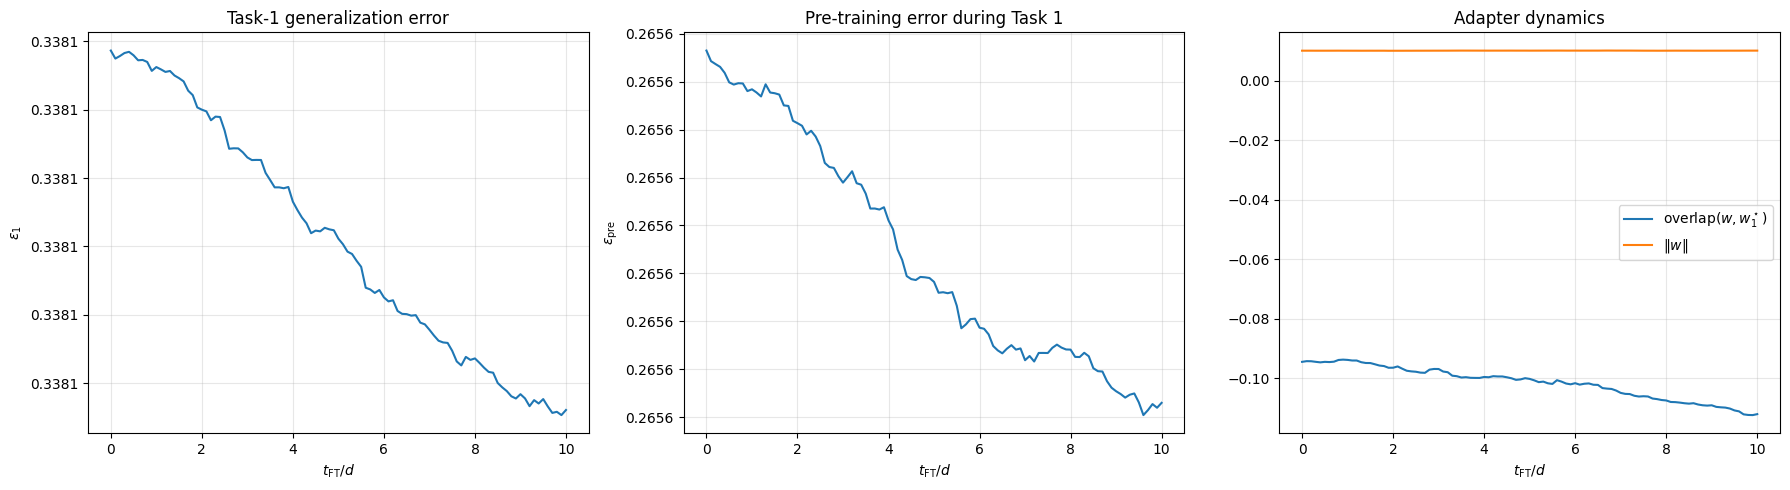

In [53]:

RUN_NAME = "scaling_d100_T5"
PRETRAIN_STEP = 0

RESULTS_ROOT = (
    REPO_ROOT
    / "results"
    / "task1_finetuning"
)

RUN_DIR = RESULTS_ROOT / RUN_NAME

METRICS_PATH = (
    RUN_DIR
    / f"step_{PRETRAIN_STEP}_task1_metrics.csv"
)


# ============================================================
# Load current metrics
# ============================================================

if not METRICS_PATH.exists():
    raise FileNotFoundError(
        f"No metrics found yet:\n{METRICS_PATH}"
    )

df = pd.read_csv(METRICS_PATH)

df = (
    df
    .sort_values("finetune_step")
    .drop_duplicates(
        subset="finetune_step",
        keep="last",
    )
    .reset_index(drop=True)
)

display(df.tail(10))


# ============================================================
# Current status
# ============================================================

last = df.iloc[-1]

print(
    f"pretraining checkpoint : {PRETRAIN_STEP:,}"
)
print(
    f"finetuning step        : "
    f"{int(last['finetune_step']):,}"
)
print(
    f"t/d                    : "
    f"{last['finetune_step_over_d']:.3f}"
)
print(
    f"Task-1 error           : "
    f"{last['task1_error']:.6e}"
)
print(
    f"Pretraining error      : "
    f"{last['pretraining_error']:.6e}"
)
print(
    f"Overlap with w1*       : "
    f"{last['overlap_w1']:.6f}"
)
print(
    f"||w||                  : "
    f"{last['w_norm']:.6f}"
)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)


# ------------------------------------------------------------
# Task-1 generalization error
# ------------------------------------------------------------

axes[0].plot(
    df["finetune_step_over_d"],
    df["task1_error"],
)

axes[0].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[0].set_ylabel(
    r"$\epsilon_1$"
)
axes[0].set_title(
    "Task-1 generalization error"
)
axes[0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Pretraining error during fine-tuning
# ------------------------------------------------------------

axes[1].plot(
    df["finetune_step_over_d"],
    df["pretraining_error"],
)

axes[1].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[1].set_ylabel(
    r"$\epsilon_{\mathrm{pre}}$"
)
axes[1].set_title(
    "Pre-training error during Task 1"
)
axes[1].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Adapter alignment
# ------------------------------------------------------------

axes[2].plot(
    df["finetune_step_over_d"],
    df["overlap_w1"],
    label=r"$\mathrm{overlap}(w,w_1^\star)$",
)

axes[2].plot(
    df["finetune_step_over_d"],
    df["w_norm"],
    label=r"$\|w\|$",
)

axes[2].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[2].set_title(
    "Adapter dynamics"
)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

for ax in axes[:2]:
    ax.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False,
    )

from matplotlib.ticker import FormatStrFormatter

axes[0].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

axes[1].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

plt.tight_layout()
plt.show()

,pretraining_step,finetune_step,finetune_step_over_d,representation_error,pretraining_error,task1_error,overlap_w1,w_norm
91,50000,910,9.1,0.562478,0.161232,0.239376,-0.112299,0.010118
92,50000,920,9.2,0.562478,0.161232,0.239376,-0.112469,0.010117
93,50000,930,9.3,0.562478,0.161232,0.239376,-0.112633,0.010118
94,50000,940,9.4,0.562478,0.161232,0.239376,-0.113017,0.010122
95,50000,950,9.5,0.562478,0.161232,0.239376,-0.113870,0.010121
96,50000,960,9.6,0.562478,0.161232,0.239376,-0.114262,0.010122
97,50000,970,9.7,0.562478,0.161232,0.239376,-0.115091,0.010127
98,50000,980,9.8,0.562478,0.161232,0.239376,-0.115338,0.010132
99,50000,990,9.9,0.562478,0.161232,0.239376,-0.115259,0.010131
100,50000,1000,10.0,0.562478,0.161232,0.239376,-0.114977,0.010131


pretraining checkpoint : 50,000
finetuning step        : 1,000
t/d                    : 10.000
Task-1 error           : 2.393762e-01
Pretraining error      : 1.612316e-01
Overlap with w1*       : -0.114977
||w||                  : 0.010131


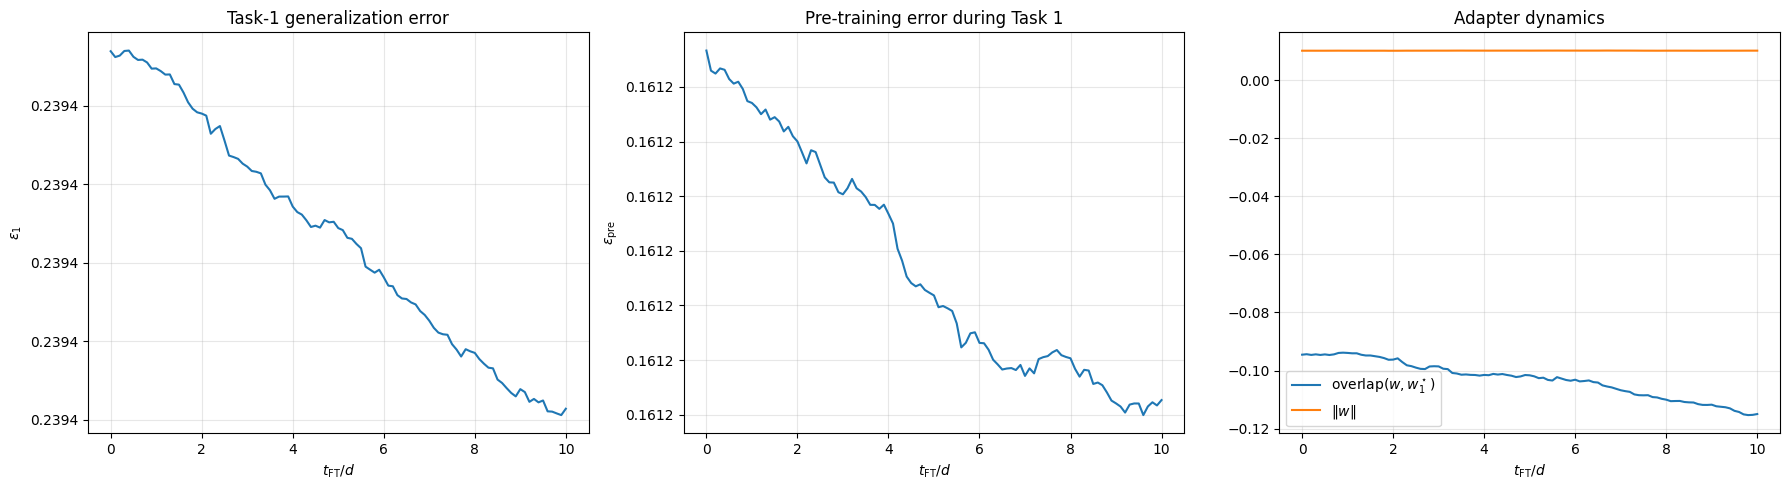

In [54]:
RUN_NAME = "scaling_d100_T5"
PRETRAIN_STEP = 50000

RESULTS_ROOT = (
    REPO_ROOT
    / "results"
    / "task1_finetuning"
)

RUN_DIR = RESULTS_ROOT / RUN_NAME

METRICS_PATH = (
    RUN_DIR
    / f"step_{PRETRAIN_STEP}_task1_metrics.csv"
)


# ============================================================
# Load current metrics
# ============================================================

if not METRICS_PATH.exists():
    raise FileNotFoundError(
        f"No metrics found yet:\n{METRICS_PATH}"
    )

df = pd.read_csv(METRICS_PATH)

df = (
    df
    .sort_values("finetune_step")
    .drop_duplicates(
        subset="finetune_step",
        keep="last",
    )
    .reset_index(drop=True)
)

display(df.tail(10))


# ============================================================
# Current status
# ============================================================

last = df.iloc[-1]

print(
    f"pretraining checkpoint : {PRETRAIN_STEP:,}"
)
print(
    f"finetuning step        : "
    f"{int(last['finetune_step']):,}"
)
print(
    f"t/d                    : "
    f"{last['finetune_step_over_d']:.3f}"
)
print(
    f"Task-1 error           : "
    f"{last['task1_error']:.6e}"
)
print(
    f"Pretraining error      : "
    f"{last['pretraining_error']:.6e}"
)
print(
    f"Overlap with w1*       : "
    f"{last['overlap_w1']:.6f}"
)
print(
    f"||w||                  : "
    f"{last['w_norm']:.6f}"
)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)


# ------------------------------------------------------------
# Task-1 generalization error
# ------------------------------------------------------------

axes[0].plot(
    df["finetune_step_over_d"],
    df["task1_error"],
)

axes[0].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[0].set_ylabel(
    r"$\epsilon_1$"
)
axes[0].set_title(
    "Task-1 generalization error"
)
axes[0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Pretraining error during fine-tuning
# ------------------------------------------------------------

axes[1].plot(
    df["finetune_step_over_d"],
    df["pretraining_error"],
)

axes[1].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[1].set_ylabel(
    r"$\epsilon_{\mathrm{pre}}$"
)
axes[1].set_title(
    "Pre-training error during Task 1"
)
axes[1].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Adapter alignment
# ------------------------------------------------------------

axes[2].plot(
    df["finetune_step_over_d"],
    df["overlap_w1"],
    label=r"$\mathrm{overlap}(w,w_1^\star)$",
)

axes[2].plot(
    df["finetune_step_over_d"],
    df["w_norm"],
    label=r"$\|w\|$",
)

axes[2].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[2].set_title(
    "Adapter dynamics"
)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

for ax in axes[:2]:
    ax.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False,
    )

from matplotlib.ticker import FormatStrFormatter

axes[0].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

axes[1].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

plt.tight_layout()
plt.show()

,pretraining_step,finetune_step,finetune_step_over_d,representation_error,pretraining_error,task1_error,overlap_w1,w_norm
191,200000,1910,19.1,0.127156,0.034466,0.130192,-0.153545,0.010202
192,200000,1920,19.2,0.127156,0.034466,0.130192,-0.154421,0.010206
193,200000,1930,19.3,0.127156,0.034466,0.130192,-0.154696,0.010208
194,200000,1940,19.4,0.127156,0.034466,0.130192,-0.155584,0.010209
195,200000,1950,19.5,0.127156,0.034466,0.130192,-0.156097,0.010210
196,200000,1960,19.6,0.127156,0.034466,0.130192,-0.155716,0.010212
197,200000,1970,19.7,0.127156,0.034466,0.130192,-0.155830,0.010219
198,200000,1980,19.8,0.127156,0.034466,0.130192,-0.155857,0.010219
199,200000,1990,19.9,0.127156,0.034466,0.130192,-0.156020,0.010211
200,200000,2000,20.0,0.127156,0.034466,0.130192,-0.156587,0.010210


pretraining checkpoint : 200,000
finetuning step        : 2,000
t/d                    : 20.000
Task-1 error           : 1.301916e-01
Pretraining error      : 3.446616e-02
Overlap with w1*       : -0.156587
||w||                  : 0.010210


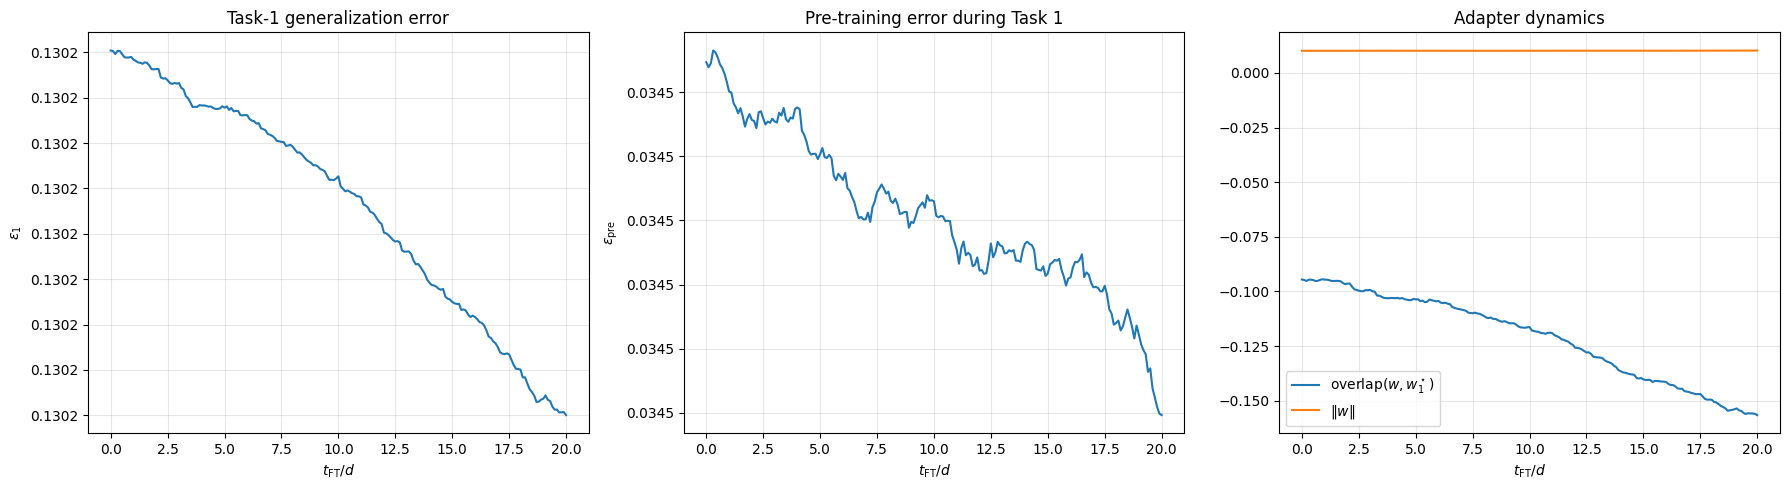

In [57]:
RUN_NAME = "scaling_d100_T5"
PRETRAIN_STEP = 200000

RESULTS_ROOT = (
    REPO_ROOT
    / "results"
    / "task1_finetuning"
)

RUN_DIR = RESULTS_ROOT / RUN_NAME

METRICS_PATH = (
    RUN_DIR
    / f"step_{PRETRAIN_STEP}_task1_metrics.csv"
)


# ============================================================
# Load current metrics
# ============================================================

if not METRICS_PATH.exists():
    raise FileNotFoundError(
        f"No metrics found yet:\n{METRICS_PATH}"
    )

df = pd.read_csv(METRICS_PATH)

df = (
    df
    .sort_values("finetune_step")
    .drop_duplicates(
        subset="finetune_step",
        keep="last",
    )
    .reset_index(drop=True)
)

display(df.tail(10))


# ============================================================
# Current status
# ============================================================

last = df.iloc[-1]

print(
    f"pretraining checkpoint : {PRETRAIN_STEP:,}"
)
print(
    f"finetuning step        : "
    f"{int(last['finetune_step']):,}"
)
print(
    f"t/d                    : "
    f"{last['finetune_step_over_d']:.3f}"
)
print(
    f"Task-1 error           : "
    f"{last['task1_error']:.6e}"
)
print(
    f"Pretraining error      : "
    f"{last['pretraining_error']:.6e}"
)
print(
    f"Overlap with w1*       : "
    f"{last['overlap_w1']:.6f}"
)
print(
    f"||w||                  : "
    f"{last['w_norm']:.6f}"
)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)


# ------------------------------------------------------------
# Task-1 generalization error
# ------------------------------------------------------------

axes[0].plot(
    df["finetune_step_over_d"],
    df["task1_error"],
)

axes[0].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[0].set_ylabel(
    r"$\epsilon_1$"
)
axes[0].set_title(
    "Task-1 generalization error"
)
axes[0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Pretraining error during fine-tuning
# ------------------------------------------------------------

axes[1].plot(
    df["finetune_step_over_d"],
    df["pretraining_error"],
)

axes[1].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[1].set_ylabel(
    r"$\epsilon_{\mathrm{pre}}$"
)
axes[1].set_title(
    "Pre-training error during Task 1"
)
axes[1].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Adapter alignment
# ------------------------------------------------------------

axes[2].plot(
    df["finetune_step_over_d"],
    df["overlap_w1"],
    label=r"$\mathrm{overlap}(w,w_1^\star)$",
)

axes[2].plot(
    df["finetune_step_over_d"],
    df["w_norm"],
    label=r"$\|w\|$",
)

axes[2].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[2].set_title(
    "Adapter dynamics"
)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

for ax in axes[:2]:
    ax.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False,
    )

from matplotlib.ticker import FormatStrFormatter

axes[0].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

axes[1].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

plt.tight_layout()
plt.show()

,pretraining_step,finetune_step,finetune_step_over_d,representation_error,pretraining_error,task1_error,overlap_w1,w_norm
991,250000,9910,99.1,0.080889,0.021803,0.121303,-0.690684,0.014173
992,250000,9920,99.2,0.080889,0.021803,0.121303,-0.691862,0.014196
993,250000,9930,99.3,0.080889,0.021803,0.121303,-0.692558,0.014210
994,250000,9940,99.4,0.080889,0.021803,0.121303,-0.693405,0.014224
995,250000,9950,99.5,0.080889,0.021803,0.121303,-0.694874,0.014244
996,250000,9960,99.6,0.080889,0.021803,0.121303,-0.695658,0.014259
997,250000,9970,99.7,0.080889,0.021803,0.121303,-0.696256,0.014277
998,250000,9980,99.8,0.080889,0.021803,0.121303,-0.696801,0.014295
999,250000,9990,99.9,0.080889,0.021803,0.121303,-0.697390,0.014306
1000,250000,10000,100.0,0.080889,0.021803,0.121303,-0.697807,0.014338


pretraining checkpoint : 250,000
finetuning step        : 10,000
t/d                    : 100.000
Task-1 error           : 1.213027e-01
Pretraining error      : 2.180273e-02
Overlap with w1*       : -0.697807
||w||                  : 0.014338


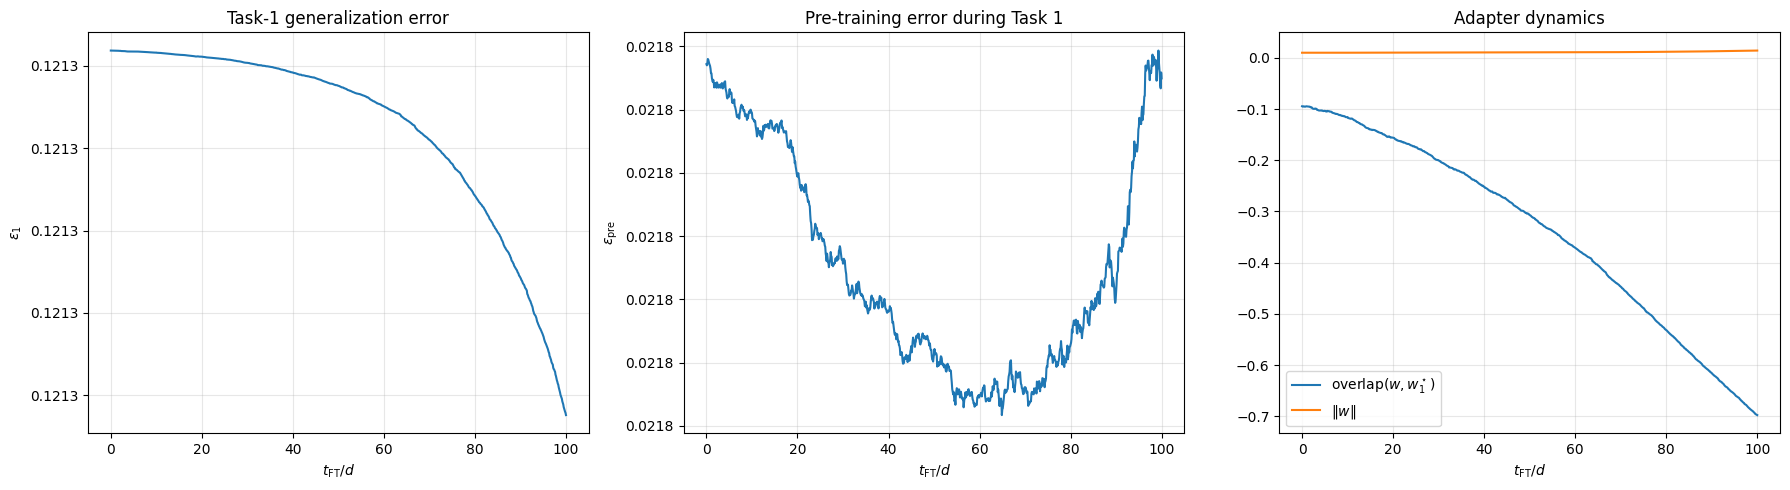

In [60]:
RUN_NAME = "scaling_d100_T5"
PRETRAIN_STEP = 250000

RESULTS_ROOT = (
    REPO_ROOT
    / "results"
    / "task1_finetuning"
)

RUN_DIR = RESULTS_ROOT / RUN_NAME

METRICS_PATH = (
    RUN_DIR
    / f"step_{PRETRAIN_STEP}_task1_metrics.csv"
)


# ============================================================
# Load current metrics
# ============================================================

if not METRICS_PATH.exists():
    raise FileNotFoundError(
        f"No metrics found yet:\n{METRICS_PATH}"
    )

df = pd.read_csv(METRICS_PATH)

df = (
    df
    .sort_values("finetune_step")
    .drop_duplicates(
        subset="finetune_step",
        keep="last",
    )
    .reset_index(drop=True)
)

display(df.tail(10))


# ============================================================
# Current status
# ============================================================

last = df.iloc[-1]

print(
    f"pretraining checkpoint : {PRETRAIN_STEP:,}"
)
print(
    f"finetuning step        : "
    f"{int(last['finetune_step']):,}"
)
print(
    f"t/d                    : "
    f"{last['finetune_step_over_d']:.3f}"
)
print(
    f"Task-1 error           : "
    f"{last['task1_error']:.6e}"
)
print(
    f"Pretraining error      : "
    f"{last['pretraining_error']:.6e}"
)
print(
    f"Overlap with w1*       : "
    f"{last['overlap_w1']:.6f}"
)
print(
    f"||w||                  : "
    f"{last['w_norm']:.6f}"
)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)


# ------------------------------------------------------------
# Task-1 generalization error
# ------------------------------------------------------------

axes[0].plot(
    df["finetune_step_over_d"],
    df["task1_error"],
)

axes[0].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[0].set_ylabel(
    r"$\epsilon_1$"
)
axes[0].set_title(
    "Task-1 generalization error"
)
axes[0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Pretraining error during fine-tuning
# ------------------------------------------------------------

axes[1].plot(
    df["finetune_step_over_d"],
    df["pretraining_error"],
)

axes[1].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[1].set_ylabel(
    r"$\epsilon_{\mathrm{pre}}$"
)
axes[1].set_title(
    "Pre-training error during Task 1"
)
axes[1].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Adapter alignment
# ------------------------------------------------------------

axes[2].plot(
    df["finetune_step_over_d"],
    df["overlap_w1"],
    label=r"$\mathrm{overlap}(w,w_1^\star)$",
)

axes[2].plot(
    df["finetune_step_over_d"],
    df["w_norm"],
    label=r"$\|w\|$",
)

axes[2].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[2].set_title(
    "Adapter dynamics"
)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

for ax in axes[:2]:
    ax.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False,
    )

from matplotlib.ticker import FormatStrFormatter

axes[0].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

axes[1].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

plt.tight_layout()
plt.show()